# Tile + Resize Preprocessor

Given a directory of source images, slice each image into square tiles at one or more tile sizes, zero-pad any tiles that fall off the edge, then resize every tile to a single fixed output size. Writes one subdirectory per tile size plus a `manifest.csv` mapping each output tile back to its source image and crop coordinates.

Top-level only (no recursion). Square tiles only. One `resize_to` applied to all tile sizes.

## 1. Config

In [1]:
from pathlib import Path

input_dir   = Path("/storage/data/bm_data")    # source images (top level only)
output_dir  = Path("/storage/data/bm_data/tiles")            # tiles + manifest written here
tile_sizes  = [512]                                   # square tile edges in pixels. E.g.: [256, 512, 1024] square on each side.
stride_frac = 1.0                                     # 1.0 = non-overlapping; 0.5 = 50% overlap
resize_to   = 640                                     # every tile is resized to this final size
out_format  = "jpg"                                   # 'jpg' or 'png'
jpeg_quality = 95                                     # only used when out_format='jpg'

output_dir.mkdir(parents=True, exist_ok=True)
for s in tile_sizes:
    (output_dir / f"tiles_{s}").mkdir(parents=True, exist_ok=True)

print("input_dir :", input_dir)
print("output_dir:", output_dir)
print("tile_sizes:", tile_sizes, "| stride_frac:", stride_frac, "| resize_to:", resize_to)

input_dir : /storage/data/bm_data
output_dir: /storage/data/bm_data/tiles
tile_sizes: [512] | stride_frac: 1.0 | resize_to: 640


## 2. Discover input images

Top-level only — files directly inside `input_dir`. Subdirectories are ignored.

In [2]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

input_files = sorted([
    f for f in input_dir.iterdir()
    if f.is_file() and f.suffix.lower() in IMAGE_EXTS
])

if not input_files:
    raise RuntimeError(f"no images found in {input_dir}")

print(f"found {len(input_files)} images")
for f in input_files[:5]:
    print(" ", f.name)
if len(input_files) > 5:
    print(f"  ... and {len(input_files) - 5} more")

found 30 images
  C_scan (1).jpg
  C_scan (10).jpg
  C_scan (11).jpg
  C_scan (12).jpg
  C_scan (13).jpg
  ... and 25 more


## 3. Tile + resize

For each image and each tile size, slide a square window with stride = `tile_size * stride_frac`. Tiles that fall partially off the right/bottom edge are zero-padded to the full tile size, then resized to `resize_to × resize_to`. Output filenames encode the tile-grid position: `<stem>_r{row}_c{col}.<ext>`.

In [3]:
import cv2
import numpy as np

_save_params = [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality] if out_format == "jpg" else []

def _tile_positions(dim, tile, stride):
    """Top-left coordinates so the last tile reaches (or pads past) the image edge."""
    if dim <= tile:
        return [0]
    n = int(np.ceil((dim - tile) / stride)) + 1
    return [i * stride for i in range(n)]

manifest_rows = []
skipped = []

for img_path in input_files:
    img = cv2.imread(str(img_path))
    if img is None:
        skipped.append(str(img_path))
        continue
    H, W = img.shape[:2]

    for tile in tile_sizes:
        stride = max(int(round(tile * stride_frac)), 1)
        ys = _tile_positions(H, tile, stride)
        xs = _tile_positions(W, tile, stride)
        out_dir_tile = output_dir / f"tiles_{tile}"

        for r, y in enumerate(ys):
            for c, x in enumerate(xs):
                y2, x2 = min(y + tile, H), min(x + tile, W)
                crop = img[y:y2, x:x2]
                pad_b = tile - crop.shape[0]
                pad_r = tile - crop.shape[1]
                if pad_b > 0 or pad_r > 0:
                    crop = cv2.copyMakeBorder(crop, 0, pad_b, 0, pad_r, cv2.BORDER_CONSTANT, value=0)
                resized = cv2.resize(crop, (resize_to, resize_to), interpolation=cv2.INTER_AREA)

                out_name = f"{img_path.stem}_r{r}_c{c}.{out_format}"
                out_path = out_dir_tile / out_name
                cv2.imwrite(str(out_path), resized, _save_params)

                manifest_rows.append({
                    "src":         img_path.name,
                    "src_w":       W,
                    "src_h":       H,
                    "tile_size":   tile,
                    "row":         r,
                    "col":         c,
                    "x":           x,
                    "y":           y,
                    "pad_right":   pad_r,
                    "pad_bottom":  pad_b,
                    "resize_to":   resize_to,
                    "out":         str(out_path.relative_to(output_dir)),
                })

print(f"wrote {len(manifest_rows)} tiles across {len(tile_sizes)} sizes")
if skipped:
    print(f"skipped {len(skipped)} unreadable files: {skipped[:3]}{'...' if len(skipped) > 3 else ''}")

wrote 1440 tiles across 1 sizes


## 4. Write manifest

In [4]:
import pandas as pd

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = output_dir / "manifest.csv"
manifest_df.to_csv(manifest_path, index=False)
print("wrote:", manifest_path)
manifest_df.head(10)

wrote: /storage/data/bm_data/tiles/manifest.csv


,src,src_w,src_h,tile_size,row,col,x,y,pad_right,pad_bottom,resize_to,out
0,C_scan (1).jpg,3800,2740,512,0,0,0,0,0,0,640,tiles_512/C_scan (1)_r0_c0.jpg
1,C_scan (1).jpg,3800,2740,512,0,1,512,0,0,0,640,tiles_512/C_scan (1)_r0_c1.jpg
2,C_scan (1).jpg,3800,2740,512,0,2,1024,0,0,0,640,tiles_512/C_scan (1)_r0_c2.jpg
3,C_scan (1).jpg,3800,2740,512,0,3,1536,0,0,0,640,tiles_512/C_scan (1)_r0_c3.jpg
4,C_scan (1).jpg,3800,2740,512,0,4,2048,0,0,0,640,tiles_512/C_scan (1)_r0_c4.jpg
5,C_scan (1).jpg,3800,2740,512,0,5,2560,0,0,0,640,tiles_512/C_scan (1)_r0_c5.jpg
6,C_scan (1).jpg,3800,2740,512,0,6,3072,0,0,0,640,tiles_512/C_scan (1)_r0_c6.jpg
7,C_scan (1).jpg,3800,2740,512,0,7,3584,0,296,0,640,tiles_512/C_scan (1)_r0_c7.jpg
8,C_scan (1).jpg,3800,2740,512,1,0,0,512,0,0,640,tiles_512/C_scan (1)_r1_c0.jpg
9,C_scan (1).jpg,3800,2740,512,1,1,512,512,0,0,640,tiles_512/C_scan (1)_r1_c1.jpg


## 5. Sanity render

Show a few tiles at each size from the first input image to confirm the cropping + padding + resize did what was expected.

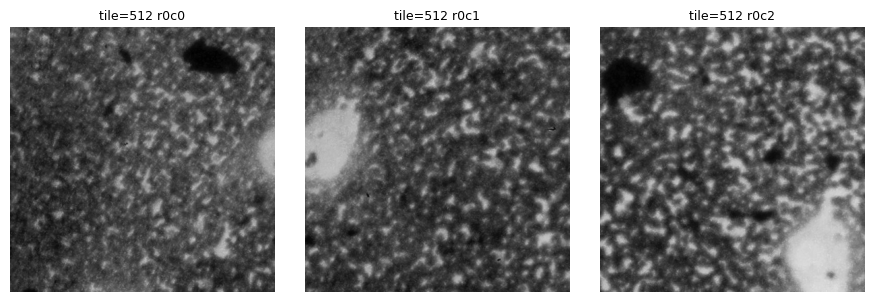

In [5]:
import matplotlib.pyplot as plt

first = input_files[0].name
preview = manifest_df[manifest_df["src"] == first]

n_per_size = 3
fig, axes = plt.subplots(len(tile_sizes), n_per_size, figsize=(3 * n_per_size, 3 * len(tile_sizes)))
if len(tile_sizes) == 1:
    axes = np.expand_dims(axes, 0)

for i, tile in enumerate(tile_sizes):
    rows = preview[preview["tile_size"] == tile].head(n_per_size)
    for j in range(n_per_size):
        ax = axes[i, j]
        ax.axis("off")
        if j >= len(rows):
            continue
        rec = rows.iloc[j]
        img = cv2.imread(str(output_dir / rec["out"]))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"tile={tile} r{rec['row']}c{rec['col']}", fontsize=9)

plt.tight_layout()
plt.show()